In [5]:
import pandas as pd
from google.colab import drive
import os # Import os for path checks
import shutil # Import shutil for directory removal

# 1. Mount Google Drive to access your files
mount_path = '/content/drive'

# Check if drive is already mounted, and unmount if force_remount is desired
# This can sometimes resolve the "Mountpoint must not already contain files" error
# which can occur even with force_remount=True in certain edge cases.
if os.path.exists(mount_path):
    if os.path.ismount(mount_path):
        print(f"Drive already mounted at {mount_path}. Attempting to unmount before force_remount.")
        try:
            drive.flush_and_unmount() # More robust unmount
            print("Drive successfully unmounted.")
        except Exception as e:
            print(f"Error during unmount: {e}. Trying alternative cleanup.")
            # If unmount failed, and it's a directory with files, attempt to remove it
            if os.path.isdir(mount_path) and os.listdir(mount_path):
                print(f"Mount point {mount_path} still contains files after unmount. Attempting to remove directory contents.")
                try:
                    # Remove directory if it's not a real mount and contains content
                    # This is a bit aggressive, used as a last resort
                    shutil.rmtree(mount_path)
                    os.makedirs(mount_path) # Recreate empty directory
                    print(f"Cleaned and recreated empty mount point: {mount_path}")
                except Exception as e_clean:
                    print(f"Error cleaning mount point manually: {e_clean}. Proceeding with mount attempt anyway.")
    elif os.path.isdir(mount_path) and os.listdir(mount_path):
        print(f"Mount point {mount_path} is a directory with contents but not mounted. Attempting to clean it.")
        try:
            shutil.rmtree(mount_path)
            os.makedirs(mount_path) # Recreate empty directory
            print(f"Cleaned and recreated empty mount point: {mount_path}")
        except Exception as e_clean:
            print(f"Error cleaning mount point manually: {e_clean}. Proceeding with mount attempt anyway.")

drive.mount(mount_path, force_remount=True)
# 2. Define the path to your dataset
# Update this if your Google Drive folder is named differently
file_path = '/content/drive/MyDrive/CV_Supercapacitor_ML/Data/CV_DATASET.xlsx'

# 3. Load the Excel data
print(f"Loading dataset from {file_path}...\n")
df = pd.read_excel(file_path)

# 4. Inspect the data to confirm it loaded correctly
print("--- Week 1 Data Inspection ---")
print(f"Dataset Shape (Rows, Columns): {df.shape}")
print(f"Columns Detected: {df.columns.tolist()}\n")

# Display the first 5 rows
display(df.head())

Mount point /content/drive is a directory with contents but not mounted. Attempting to clean it.
Cleaned and recreated empty mount point: /content/drive
Mounted at /content/drive
Loading dataset from /content/drive/MyDrive/CV_Supercapacitor_ML/Data/CV_DATASET.xlsx...

--- Week 1 Data Inspection ---
Dataset Shape (Rows, Columns): (216200, 7)
Columns Detected: ['Potential', 'Current', 'OXIDATION', 'Zn/Co_Conc', 'SCAN_RATE', 'ZN', 'CO']



,Potential,Current,OXIDATION,Zn/Co_Conc,SCAN_RATE,ZN,CO
0,-0.500,-0.01218,1,0.0,10,1,0
1,-0.499,-0.01188,1,0.0,10,1,0
2,-0.498,-0.01158,1,0.0,10,1,0
3,-0.497,-0.01128,1,0.0,10,1,0
4,-0.496,-0.01098,1,0.0,10,1,0


In [6]:
# ==========================================
# WEEK 2: Data Preprocessing Pipeline
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate Target (y) and Features (X)
target_col = 'Current'

# y is the output we want to predict
y = df[target_col]

# X contains all the inputs (Potential, OXIDATION, SCAN_RATE, etc.)
X = df.drop(target_col, axis=1)

print("--- Data Split ---")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}\n")

# 2. Train-Test Split (80% Train, 20% Test)
# random_state=42 ensures you get the exact same split every time you run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows\n")

# 3. Standard Scaling
# This gives all numerical columns a mean of 0 and a variance of 1
scaler = StandardScaler()

# Fit the math on the training data, then transform it
X_train_scaled = scaler.fit_transform(X_train)

# Only transform the testing data (never fit on test data to prevent cheating)
X_test_scaled = scaler.transform(X_test)

print("✅ Week 2 Preprocessing Complete! Data is split, scaled, and ready for modeling.")

--- Data Split ---
Features (X) shape: (216200, 6)
Target (y) shape: (216200,)

Training set: 172960 rows
Testing set: 43240 rows

✅ Week 2 Preprocessing Complete! Data is split, scaled, and ready for modeling.


In [7]:
# ==========================================
# WEEK 3 - PART 1: Artificial Neural Network
# ==========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np # Added numpy for the square root math

print("Building Artificial Neural Network (ANN)...")

ann_model = Sequential()
ann_model.add(Dense(100, activation='relu', input_dim=X_train_scaled.shape[1]))
ann_model.add(Dense(80, activation='relu'))
ann_model.add(Dense(1, activation='linear'))

ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Training started. This may take a minute or two...\n")
history = ann_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

y_pred_ann = ann_model.predict(X_test_scaled)
r2_ann = r2_score(y_test, y_pred_ann)

# FIXED: Using numpy to calculate the square root safely
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))

print("\n✅ ANN Training Complete!")
print(f"ANN R² Score: {r2_ann:.4f} (Aiming for >0.97)")
print(f"ANN RMSE:     {rmse_ann:.6f}")

Building Artificial Neural Network (ANN)...
Training started. This may take a minute or two...

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4324/4324 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 1.5665e-04 - mae: 0.0060 - val_loss: 2.5705e-05 - val_mae: 0.0040
Epoch 2/50
4324/4324 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 2.1293e-05 - mae: 0.0034 - val_loss: 5.3762e-06 - val_mae: 0.0018
Epoch 3/50
4324/4324 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 6.6446e-06 - mae: 0.0019 - val_loss: 3.9949e-06 - val_mae: 0.0016
Epoch 4/50
4324/4324 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2.6377e-06 - mae: 0.0012 - val_loss: 1.8283e-06 - val_mae: 9.0798e-04
Epoch 5/50
4324/4324 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 1.8058e-06 - mae: 8.8471e-04 - val_loss: 1.6292e-06 - val_mae: 9.0930e-04
Epoch 6/50
4324/4324 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 1.5699e-06 - mae: 7.9803e-04 - val_loss: 1.7603e-06 - val_mae: 8.3510e-04
Epoch 7/50
4324/4324 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 1.5043e-06 - mae: 7.7008e-04 - val_loss: 1.3940e-06 - val_mae: 7.1354e-04
Epoch 8/50
4324/4324 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 1.4389e-06 - mae:

In [8]:
# ==========================================
# WEEK 3 - PART 2: Random Forest Model
# ==========================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Building Random Forest (RF) Model...")

rf_model = RandomForestRegressor(
    n_estimators=40,
    max_depth=11,
    random_state=42,
    n_jobs=-1
)

print("Training started...")
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
r2_rf = r2_score(y_test, y_pred_rf)

# FIXED: Using numpy to calculate the square root safely
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("\n✅ Random Forest Training Complete!")
print(f"RF R² Score: {r2_rf:.4f} (Aiming for >0.97)")
print(f"RF RMSE:     {rmse_rf:.6f}")

Building Random Forest (RF) Model...
Training started...

✅ Random Forest Training Complete!
RF R² Score: 0.9757 (Aiming for >0.97)
RF RMSE:     0.001154


In [9]:
# ==========================================
# WEEK 4 - PART 1: XGBoost Model
# ==========================================
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Building XGBoost (XGB) Model...")

# 1. Define the XGB Architecture
xgb_model = XGBRegressor(
    n_estimators=100,      # Number of boosting rounds
    learning_rate=0.1,     # Step size shrinkage (eta)
    max_depth=6,           # Maximum depth of a tree
    random_state=42,
    n_jobs=-1
)

# 2. Train the Model
print("Training started...")
xgb_model.fit(X_train_scaled, y_train)

# 3. Evaluate the Model
y_pred_xgb = xgb_model.predict(X_test_scaled)
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("\n✅ XGBoost Training Complete!")
print(f"XGB R² Score: {r2_xgb:.4f}")
print(f"XGB RMSE:     {rmse_xgb:.6f}")

Building XGBoost (XGB) Model...
Training started...

✅ XGBoost Training Complete!
XGB R² Score: 0.9774
XGB RMSE:     0.001113


In [10]:
# ==========================================
# WEEK 4 - PART 2: Stacked Meta-Model (Ridge)
# ==========================================
from sklearn.linear_model import RidgeCV
import pandas as pd

print("Building the Stacked Meta-Model...")

# 1. Generate Predictions from the Training Data
# We need to flatten the ANN output so it matches the shape of the others
train_pred_ann = ann_model.predict(X_train_scaled, verbose=0).flatten()
train_pred_rf = rf_model.predict(X_train_scaled)
train_pred_xgb = xgb_model.predict(X_train_scaled)

# Create a new dataset where the FEATURES are the predictions of the 3 base models
X_meta_train = pd.DataFrame({
    'ANN': train_pred_ann,
    'RF': train_pred_rf,
    'XGB': train_pred_xgb
})

# 2. Generate Predictions from the Testing Data
test_pred_ann = y_pred_ann.flatten()
test_pred_rf = y_pred_rf
test_pred_xgb = y_pred_xgb

X_meta_test = pd.DataFrame({
    'ANN': test_pred_ann,
    'RF': test_pred_rf,
    'XGB': test_pred_xgb
})

# 3. Train the Meta-Model (Ridge Regression)
# RidgeCV automatically tests different alpha (regularization) values to find the best fit
meta_model = RidgeCV(alphas=[0.1, 1.0, 10.0])
meta_model.fit(X_meta_train, y_train)

# 4. Final Evaluation
y_pred_meta = meta_model.predict(X_meta_test)
r2_meta = r2_score(y_test, y_pred_meta)
rmse_meta = np.sqrt(mean_squared_error(y_test, y_pred_meta))

print("\n✅ Meta-Model Training Complete!")
print("--- FINAL ACCURACY ---")
print(f"Meta-Model R² Score: {r2_meta:.4f} (Aiming for ~0.977)")
print(f"Meta-Model RMSE:     {rmse_meta:.6f}")
print(f"Ridge Alpha chosen:  {meta_model.alpha_}")

Building the Stacked Meta-Model...

✅ Meta-Model Training Complete!
--- FINAL ACCURACY ---
Meta-Model R² Score: 0.9787 (Aiming for ~0.977)
Meta-Model RMSE:     0.001080
Ridge Alpha chosen:  0.1


Loading completely unseen 60mV Dataset...
Generating predictions from base models...
Generating final Meta-Model predictions...

--- REAL WORLD TEST RESULTS ---
Unseen Data R² Score: 0.9966
Unseen Data RMSE:     0.000455


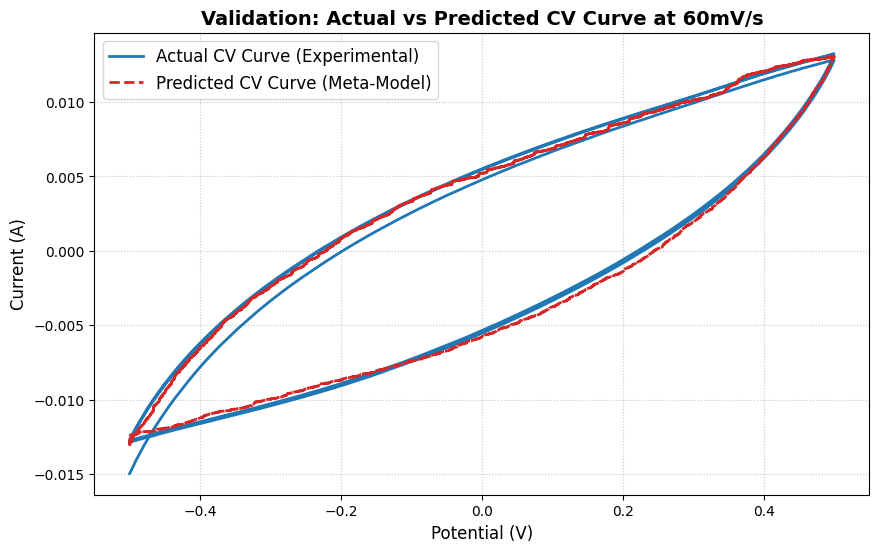

In [11]:
# ==========================================
# WEEK 5: Real-World Test & CV Curve Visualization
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

print("Loading completely unseen 60mV Dataset...")

# 1. Load the out-of-sample test data
# Make sure this exact file is in your CV_Project folder in Google Drive
unseen_file_path = '/content/drive/MyDrive/CV_Supercapacitor_ML/Data/60MV_CV.xlsx'
df_unseen = pd.read_excel(unseen_file_path)

# 2. Separate Features and Target
target_col = 'Current'
y_unseen = df_unseen[target_col]
X_unseen = df_unseen.drop(target_col, axis=1)

# 3. Scale the new data
# CRITICAL: We use transform() NOT fit_transform() so it uses the exact same math as the training data
X_unseen_scaled = scaler.transform(X_unseen)

# 4. Generate Base Model Predictions
print("Generating predictions from base models...")
unseen_pred_ann = ann_model.predict(X_unseen_scaled, verbose=0).flatten()
unseen_pred_rf = rf_model.predict(X_unseen_scaled)
unseen_pred_xgb = xgb_model.predict(X_unseen_scaled)

# 5. Stack the Predictions for the Meta-Model
X_meta_unseen = pd.DataFrame({
    'ANN': unseen_pred_ann,
    'RF': unseen_pred_rf,
    'XGB': unseen_pred_xgb
})

# 6. Final Meta-Model Prediction
print("Generating final Meta-Model predictions...")
final_predictions = meta_model.predict(X_meta_unseen)

# 7. Calculate Final Out-of-Sample Metrics
final_r2 = r2_score(y_unseen, final_predictions)
final_rmse = np.sqrt(mean_squared_error(y_unseen, final_predictions))

print("\n--- REAL WORLD TEST RESULTS ---")
print(f"Unseen Data R² Score: {final_r2:.4f}")
print(f"Unseen Data RMSE:     {final_rmse:.6f}")

# 8. Plot the actual vs predicted CV Curve
plt.figure(figsize=(10, 6))

# Plot the real experimental curve in blue
plt.plot(df_unseen['Potential'], y_unseen, label='Actual CV Curve (Experimental)', color='#1f77b4', linewidth=2)

# Plot our machine learning prediction in red dashes
plt.plot(df_unseen['Potential'], final_predictions, label='Predicted CV Curve (Meta-Model)', color='#d62728', linestyle='--', linewidth=2)

plt.xlabel('Potential (V)', fontsize=12)
plt.ylabel('Current (A)', fontsize=12)
plt.title('Validation: Actual vs Predicted CV Curve at 60mV/s', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# Show the plot
plt.show()

In [12]:
# ==========================================
# WEEK 6: Exporting Trained Models
# ==========================================
import joblib
import os

print("Saving models to Google Drive...")

# 1. Dynamically set the path to your 'CV_Supercapacitor_ML' folder
base_path = '/content/drive/MyDrive/CV_Supercapacitor_ML/'
models_dir = os.path.join(base_path, 'models')

# 2. Automatically create the models folder if it doesn't exist
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    print(f"Created new folder: {models_dir}")
else:
    print(f"Found existing folder: {models_dir}")

# 3. Save the Artificial Neural Network
ann_path = os.path.join(models_dir, 'ann_model.keras')
ann_model.save(ann_path)
print(f"Saved ANN to: {ann_path}")

# 4. Save the Traditional Models & Meta-Model
joblib.dump(rf_model, os.path.join(models_dir, 'rf_model.pkl'))
joblib.dump(xgb_model, os.path.join(models_dir, 'xgb_model.pkl'))
joblib.dump(meta_model, os.path.join(models_dir, 'meta_stacked_model.pkl'))
joblib.dump(scaler, os.path.join(models_dir, 'standard_scaler.pkl'))

print("\n✅ All models successfully secured in your project folder!")

Saving models to Google Drive...
Found existing folder: /content/drive/MyDrive/CV_Supercapacitor_ML/models
Saved ANN to: /content/drive/MyDrive/CV_Supercapacitor_ML/models/ann_model.keras

✅ All models successfully secured in your project folder!
